# EDA NOTEBOOK

## I. Introduction and Setup

### 1. Introduction

**Notebook này thực hiện Exploratory Data Analysis (EDA)** trên bộ dữ liệu 
[UCI Heart Disease Dataset] để hiểu sâu về cấu trúc dữ liệu
, phân phối của các đặc trưng, mối tương quan giữa các biến,
và các vấn đề cần xử lý trước khi xây dựng mô hình.

### 2. EDA Roadmap

| Bước | Nội dung | Người thực hiện |
|------|----------|-----------------|
| I | Introduction & Setup | Cả nhóm |
| II | Target Analysis | Quyên |
| III | Categorical Analysis | Quyên |
| IV | Distribution Analysis | Phát |
| V | Correlation Analysis | Phát |
| VI | Outlier Detection | Xuyên |
| VII | Statistical Tests | Xuyên |
| VIII | Key Findings | Cả nhóm |

### 3. Environment Setup and Library Import

In [1]:
#import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

#hàm load data set để handle error và tái sử dụng
def load_dataset(dataset_path):
    """
    Kiểm tra và lấy dữ liệu từ file csv 
    Args:
        dataset_path (str): đường dẫn file csv 
    Returns:
        pandas.dataframe: bảng dữ liệu đã được đọc
    """
    if not os.path.exists(dataset_path):
        print("Không tìm thấy file!")
        return None
    
    try: 
        df = pd.read_csv(dataset_path)
        print("Đã tải dữ liệu thành công!")
        return df
    except Exception as e:
        print(f"Đã xảy ra lỗi trong quá trình tải: {e}")
        return None
    
#define dataset path
dataset_path = "../data/dataset.csv"

#load data
df = load_dataset(dataset_path=dataset_path)

Đã tải dữ liệu thành công!


### 4. Data Overview
Đây là tập dữ liệu thô được lấy từ nguồn **[UCI Heart Disease Dataset]**
Link: https://archive.ics.uci.edu/dataset/45/heart+disease

In [2]:
#Hiển thị tổng quan về các thông tin của dataset: số hàng, số cột, kiểu dữ liệu, số giá trị non-null mỗi cột, ...
print("Tổng quan cấu trúc dataset:")

#Thông tin số dòng số cột
print(f"- Dataset có {df.shape[0]} dòng và {df.shape[1]} cột.")

Tổng quan cấu trúc dataset:
- Dataset có 920 dòng và 16 cột.


In [3]:
#Thông tin kiểu dữ liệu từng cột, số giá trị non-null
print("- Các thông tin cơ bản:")
df.info()

- Các thông tin cơ bản:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [4]:
#Thông tin về trung bình, độ lệch chuẩn, tứ phân vị, giá trị nhỏ nhất lớn nhất
print("- Các thông tin thống kê:")
df.describe()

- Các thông tin thống kê:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
#5 hàng dữ liệu đầu tiên
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### 5. Add target variable
Sau khi xem xét các thuộc tính của dataset, nhóm nhận thấy rằng thuộc tính 'num' của dataset là thuộc tính giúp phân loại người bệnh và không có bệnh. Nhưng giá trị của thuộc tính num này là kiểu int64 có giá trị từ **0 đến 4**, trong đó, 0 là không bệnh và 1 2 3 là có bệnh. Để phục vụ giải quyết bài toán **Classification**, nhóm quyết định thêm cột 'target' kiểu binary:
* 0: Không bệnh (num = 0)
* 1: Có bệnh (num = 1, 2, 3, 4)
Cột 'num' được giữu lại để tham khảo sau này và đúng với nguyên tắc không chỉnh sửa dữ liệu thô.


In [6]:
#Dùng hàm astype để convert tất cả dữ liệu trong cột từ bool thành int
df['target'] = (df['num'] > 0).astype(int)

#Hiển thị dữ liệu đã thêm target
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


## II. Target Analysis

**Phân tích biến mục tiêu (Target Analysis):** Là quá trình thống kê và hình ảnh hóa để hiểu rõ đặc điểm, phân phối và tính chất của biến dự đoán trước khi xây dựng mô hình. Phân tích biến mục tiêu giúp ta xác định:
*     Dữ liệu có cân bằng hay không?
*     Chỉ số đánh giá phù hợp?
*     Các vấn đề về chất lượng dữ liệu?


Trong phần này, nhóm sử dụng biểu đồ **CountPlot** để thực hiện Target Analysis (Phân tích biến mục tiêu). Biến mục tiêu được xác định là **cột 'num'** – cột lưu trữ kết quả chẩn đoán bệnh tim của bệnh nhân. Để phù hợp với yêu cầu bài toán phân loại (có bệnh/không có bệnh), nhóm đã tiến hành nhị phân hóa cột dữ liệu này, trong đó giá trị 0 đại diện cho trạng thái **'Không bệnh'** và các giá trị từ 1 đến 4 đại diện cho trạng thái **'Có bệnh'**.

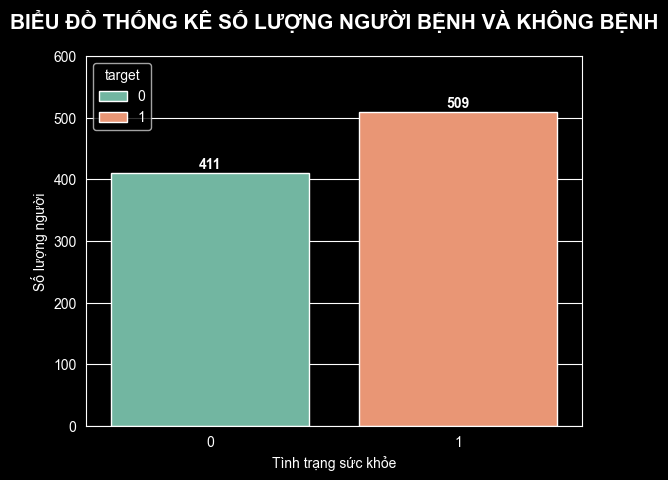

In [7]:

# Vẽ biểu đồ bằng thư viện Seaborn
ax=sns.countplot(data=df, x='target',
              hue='target',
              palette="Set2")
#gan nhan

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold', padding=1)
#Đặt tên biểu đồ và các trụ
plt.ylim(0,600)
plt.title(f'BIỂU ĐỒ THỐNG KÊ SỐ LƯỢNG NGƯỜI BỆNH VÀ KHÔNG BỆNH',
          fontsize=15,
          fontweight='bold',
          pad=20)
plt.xlabel('Tình trạng sức khỏe')
plt.ylabel('Số lượng người')

#hiện biểu đồ
plt.show()

**Nhận xét:**
* **Số lượng:** Có **411** trường hợp không mắc bệnh và **509** trường hợp mắc bệnh.
* **Độ cân bằng:** Dữ liệu có tính cân bằng cao.
* **Chiến lược đánh giá:** Ưu tiên chỉ số Recall để giảm thiểu tỷ lệ bỏ sót bệnh nhân.

**Chú thích:**
* 0:Không bệnh
* 1:Có bệnh

## II. Categorical Analysis
**Phân tích biến phân loại(Categorical Analysis)** là việc nghiên cứu các biến chứa các giá trị định tính, nhãn hoặc các nhóm hữu hạn (ví dụ: giới tính, quốc gia, loại sản phẩm) thay vì các con số liên tục. Mục tiêu chính của bước này là hiểu được sự phân phối, tần suất xuất hiện và mối quan hệ của các nhóm dữ liệu này với các biến khác.

Trong phần này nhóm sử dụng biểu đồ CountPlot/Bar Chart để phân tích biến phân loại, nhóm sẽ vẽ 3 biểu đồ để xem tỉ lệ bệnh theo giới tính, theo loại đau ngực và xem loại đau ngực nào dễ mắc bệnh nhất.



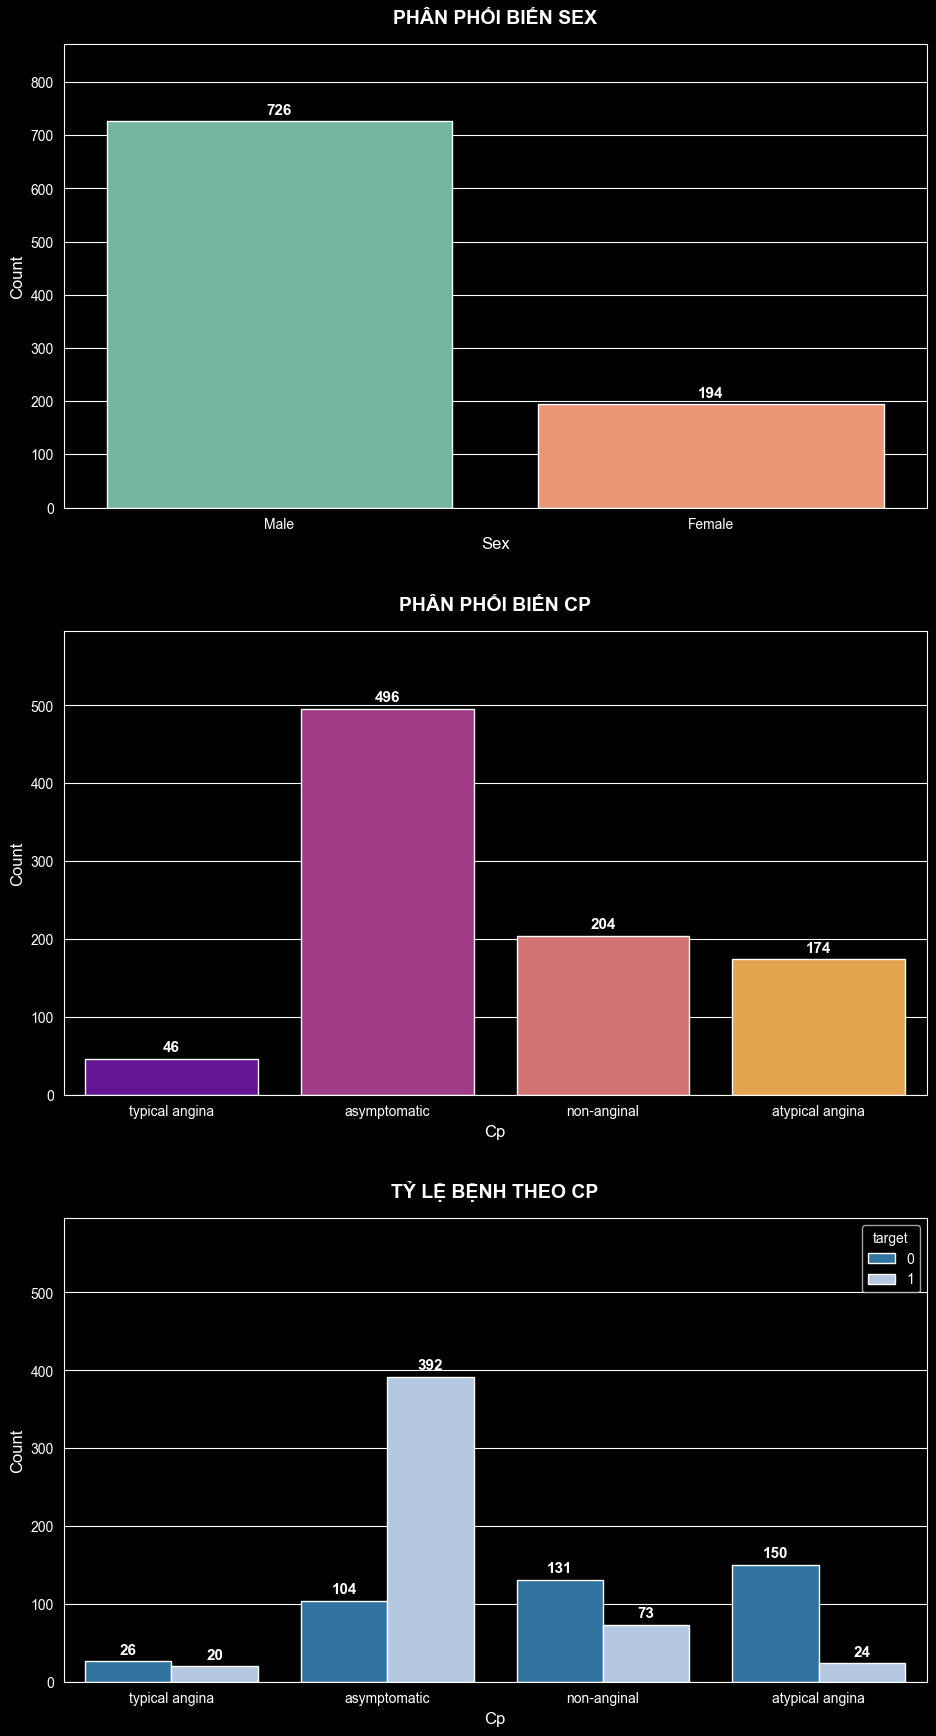

In [8]:
#Chuẩn bị dữ liệu mục tiêu

#Cấu hình danh sách các biểu đồ
configs = [
    ('sex', 'sex', 'Set2'),          # Biểu đồ 1: Phân phối giới tính
    ('cp', 'cp', 'plasma'),          # Biểu đồ 2: Phân phối loại đau ngực
    ('cp', 'target', 'tab20')   # Biểu đồ 3: Đau ngực theo tình trạng bệnh
]

#Tạo khung hình: n hàng (tương ứng với số lượng configs), 1 cột
fig, axes = plt.subplots(nrows=len(configs), ncols=1, figsize=(10, 6 * len(configs)))

# Vòng lặp vẽ từng biểu đồ
for i, (x_col, h_col, pal) in enumerate(configs):
    ax = axes[i] # Lấy trục tương ứng ở hàng thứ i

    # Kiểm tra xem đây là biểu đồ đơn biến hay đa biến để đặt tên
    is_univariate = (x_col == h_col)

    # Vẽ biểu đồ
    sns.countplot(data=df, x=x_col, hue=h_col, palette=pal, ax=ax, legend=not is_univariate)

    # Thêm số liệu trên đầu cột
    for container in ax.containers:
        ax.bar_label(container, fontsize=11, fontweight='bold', padding=3)

    # Tinh chỉnh tiêu đề và nhãn
    title_text = f'PHÂN PHỐI BIẾN {x_col.upper()}' if is_univariate else f'TỶ LỆ BỆNH THEO {x_col.upper()}'
    ax.set_title(title_text, pad=15, fontsize=14, fontweight='bold')
    ax.set_xlabel(x_col.capitalize(), fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

    # Xoay chữ cho trục X nếu cần
    if x_col in ['cp', 'dataset']:
        ax.tick_params(axis='x', rotation=0) # Có thể để 0 vì mỗi hàng 1 biểu đồ rất rộng

    # Chỉnh ylim để không bị mất số liệu trên đầu cột
    counts = df[x_col].value_counts()
    ax.set_ylim(0, counts.max() * 1.2)

# 5. Tối ưu khoảng cách giữa các hàng
plt.tight_layout(pad=3.0)
plt.show()

**Nhận xét:**

**-Tại biểu đồ 1:** Dữ liệu có sự mất cân bằng giới tính. Số lượng Nam giới tham gia khảo sát đông hơn rất nhiều so với Nữ giới (khoảng 79% là Nam).

**-Tại biểu đồ 2:** Đau ngực loại asymptomatic (không triệu chứng) chiếm tỷ lệ cao nhất (hơn 50%). Trong khi các loại đau thắt ngực điển hình (typical angina) lại chiếm tỷ lệ thấp nhất.

**-Tại biểu đồ 3:** Sự tương quan giữa các loại đau thắt ngực và có hay không có bệnh,   kết quả loại asymptomatic(không triệu chứng) có tỉ lệ mắc bệnh cao nhất.

**=>>** Tình trạng bệnh diễn biến âm thầm ở nhóm không triệu chứng (chiếm tỷ lệ mắc bệnh cao nhất) cho thấy không thể chỉ dựa vào cảm giác đau ngực chủ quan để chẩn đoán, mà cần kết hợp các chỉ số xét nghiệm chuyên sâu để đưa ra kết quả chính xác.

**Chú thích:**
* 0:Không bệnh
* 1:Có bệnh
